# METRICS

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import numpy as np
import re
from scipy.stats import wilcoxon
import sqlite3
from scipy.stats import wilcoxon


In [2]:
all_dfs = []

for file in Path(".").glob("parent_child_metrics*.csv"):

    df = pd.read_csv(file)

    filename = file.stem

    if "noDiff" in filename:
        df["type"] = "No Diffusion"
    else:
        df["type"] = "Diffusion"

    df["file"] = filename

    all_dfs.append(df)

data = pd.concat(all_dfs, ignore_index=True)

data.head()

,seed,generation,child_id,parent1_id,parent2_id,morph_diff_p1,morph_diff_p2,tf_diff_p1,tf_diff_p2,activation_diff_p1,activation_diff_p2,trajectory_diff_p1,trajectory_diff_p2,type,file
0,1675610640,2,101,19,80,12,8,9.6922,7.0050,2,3,2273.0531,1011.4455,No Diffusion,parent_child_metrics_noDiff10
1,1675610640,2,102,87,4,11,9,10.5366,9.8563,0,1,1248.0188,2247.3008,No Diffusion,parent_child_metrics_noDiff10
2,1675610640,2,103,22,37,10,7,19.5953,10.1380,0,2,3223.8169,2634.8280,No Diffusion,parent_child_metrics_noDiff10
3,1675610640,2,104,87,49,9,10,9.3969,26.7479,0,0,2442.9604,4716.9151,No Diffusion,parent_child_metrics_noDiff10
4,1675610640,2,105,89,18,12,7,13.7958,8.5429,1,2,2920.8855,1961.7362,No Diffusion,parent_child_metrics_noDiff10


In [3]:
data[["file", "type", "seed"]].drop_duplicates().sort_values("file")

,file,type,seed
29700,parent_child_metrics_diff1,Diffusion,741426186
148500,parent_child_metrics_diff10,Diffusion,1675610640
19800,parent_child_metrics_diff2,Diffusion,2740078919
9900,parent_child_metrics_diff3,Diffusion,2068761028
59400,parent_child_metrics_diff4,Diffusion,3623061707
49500,parent_child_metrics_diff5,Diffusion,2024494734
79200,parent_child_metrics_diff6,Diffusion,3510944332
89100,parent_child_metrics_diff7,Diffusion,698244043
138600,parent_child_metrics_diff8,Diffusion,2000041698
128700,parent_child_metrics_diff9,Diffusion,1249147593


In [4]:
def average_morphological_divergence(df, by_generation=False):
    df = df.copy()
    df["morphological_divergence"] = (df["morph_diff_p1"] + df["morph_diff_p2"]) / 2

    if by_generation:
        return df.groupby("generation")["morphological_divergence"].agg(["mean", "std"]).reset_index()

    return df["morphological_divergence"].agg(["mean", "std"])


def average_tf_concentration_divergence(df, by_generation=False):
    df = df.copy()
    df["tf_concentration_divergence"] = (df["tf_diff_p1"] + df["tf_diff_p2"]) / 2

    if by_generation:
        return df.groupby("generation")["tf_concentration_divergence"].agg(["mean", "std"]).reset_index()

    return df["tf_concentration_divergence"].agg(["mean", "std"])


def average_tf_activation_pattern_divergence(df, by_generation=False):
    df = df.copy()
    df["tf_activation_pattern_divergence"] = (df["activation_diff_p1"] + df["activation_diff_p2"]) / 2

    if by_generation:
        return df.groupby("generation")["tf_activation_pattern_divergence"].agg(["mean", "std"]).reset_index()

    return df["tf_activation_pattern_divergence"].agg(["mean", "std"])


def average_tf_trajectory_divergence(df, by_generation=False):
    df = df.copy()
    df["tf_trajectory_divergence"] = (df["trajectory_diff_p1"] + df["trajectory_diff_p2"]) / 2

    if by_generation:
        return df.groupby("generation")["tf_trajectory_divergence"].agg(["mean", "std"]).reset_index()

    return df["tf_trajectory_divergence"].agg(["mean", "std"])

In [5]:
df = pd.read_csv("parent_child_metrics_diff1.csv")

average_morphological_divergence(df)

mean    10.102424
std      4.487922
Name: morphological_divergence, dtype: float64

In [6]:
def analyze_all_files():

    results = []

    for file in Path(".").glob("parent_child_metrics*.csv"):

        df = pd.read_csv(file)

        morph = average_morphological_divergence(df)
        tf_conc = average_tf_concentration_divergence(df)
        tf_act = average_tf_activation_pattern_divergence(df)
        tf_traj = average_tf_trajectory_divergence(df)

        results.append({
            "file": file.stem,
            "morph_mean": morph["mean"],
            "morph_std": morph["std"],
            "tf_conc_mean": tf_conc["mean"],
            "tf_conc_std": tf_conc["std"],
            "tf_act_mean": tf_act["mean"],
            "tf_act_std": tf_act["std"],
            "tf_traj_mean": tf_traj["mean"],
            "tf_traj_std": tf_traj["std"]
        })

    return pd.DataFrame(results)

In [7]:
results = analyze_all_files()
results

,file,morph_mean,morph_std,tf_conc_mean,tf_conc_std,tf_act_mean,tf_act_std,tf_traj_mean,tf_traj_std
0,parent_child_metrics_noDiff10,9.895253,4.445457,7.446286,5.442940,1.130000,0.857464,1911.224276,1081.457510
1,parent_child_metrics_diff3,8.854747,4.732523,6.848703,4.268508,1.129192,0.898740,1834.282707,1106.606078
2,parent_child_metrics_diff2,9.462626,3.801796,5.408838,4.275510,0.773384,0.723652,1803.320869,978.121966
3,parent_child_metrics_diff1,10.102424,4.487922,9.066808,5.395276,1.139899,0.856495,2425.660311,1276.417125
4,parent_child_metrics_noDiff9,8.774697,4.067266,10.390608,5.631402,1.214091,0.805952,2532.763177,1179.415087
5,parent_child_metrics_diff5,7.558434,5.285891,3.821842,4.162890,0.723131,0.759098,1407.133911,1199.572454
6,parent_child_metrics_diff4,6.717879,4.320596,4.043966,4.066680,1.022222,0.791447,1256.965311,1025.821994
7,parent_child_metrics_noDiff8,10.297273,4.678405,12.559429,7.373885,1.092071,0.940514,2631.749673,1450.409755
8,parent_child_metrics_diff6,7.643081,3.872215,3.091414,3.123716,0.664394,0.670003,1138.077053,798.850858
9,parent_child_metrics_diff7,8.746667,4.340530,5.995296,4.286677,0.927576,0.749184,1879.926987,1071.563145


In [8]:
results["condition"] = results["file"].apply(
    lambda x: "No Diffusion" if "noDiff" in x else "Diffusion"
)

In [9]:
results.groupby("condition").mean(numeric_only=True)

,morph_mean,morph_std,tf_conc_mean,tf_conc_std,tf_act_mean,tf_act_std,tf_traj_mean,tf_traj_std
condition,,,,,,,,
Diffusion,8.688419,4.285533,5.538927,4.224698,0.954939,0.764745,1661.743722,1042.403367
No Diffusion,8.674136,4.678996,8.460668,5.986633,0.965434,0.819101,1928.263907,1217.659329


In [10]:
def analyze_all_files_by_generation():

    results = []

    for file in Path(".").glob("parent_child_metrics*.csv"):

        df = pd.read_csv(file)

        morph = average_morphological_divergence(df, by_generation=True)
        tf_conc = average_tf_concentration_divergence(df, by_generation=True)
        tf_act = average_tf_activation_pattern_divergence(df, by_generation=True)
        tf_traj = average_tf_trajectory_divergence(df, by_generation=True)

        for i in range(len(morph)):
            results.append({
                "file": file.stem,
                "generation": morph.loc[i, "generation"],

                "morph_mean": morph.loc[i, "mean"],
                "morph_std": morph.loc[i, "std"],

                "tf_conc_mean": tf_conc.loc[i, "mean"],
                "tf_conc_std": tf_conc.loc[i, "std"],

                "tf_act_mean": tf_act.loc[i, "mean"],
                "tf_act_std": tf_act.loc[i, "std"],

                "tf_traj_mean": tf_traj.loc[i, "mean"],
                "tf_traj_std": tf_traj.loc[i, "std"]
            })

    return pd.DataFrame(results)

In [11]:
generation_results = analyze_all_files_by_generation()
generation_results.head(20)

,file,generation,morph_mean,morph_std,tf_conc_mean,tf_conc_std,tf_act_mean,tf_act_std,tf_traj_mean,tf_traj_std
0,parent_child_metrics_noDiff10,2,9.375,3.258536,11.380059,6.236486,1.185,0.650000,2418.578439,1351.517329
1,parent_child_metrics_noDiff10,3,10.910,3.426265,13.129740,7.219850,1.150,0.733402,2957.959149,1319.312874
2,parent_child_metrics_noDiff10,4,10.785,3.662018,12.477476,5.716531,1.185,0.653873,2726.510853,1199.214162
3,parent_child_metrics_noDiff10,5,10.420,3.543895,11.696506,5.250342,1.135,0.713701,2519.808361,986.724449
4,parent_child_metrics_noDiff10,6,10.080,3.320217,10.115932,4.893674,1.260,0.780054,2229.073006,887.449712
5,parent_child_metrics_noDiff10,7,10.120,3.322041,10.319370,5.612603,1.145,0.789115,2217.376602,1036.802647
6,parent_child_metrics_noDiff10,8,10.565,3.888376,10.035450,5.927903,1.105,0.648600,2144.952355,1061.618705
7,parent_child_metrics_noDiff10,9,10.135,3.954830,9.677087,6.409100,1.035,0.711575,2145.057630,1295.476839
8,parent_child_metrics_noDiff10,10,10.255,4.389206,8.798202,6.367107,1.120,0.732093,2118.259295,1229.712977
9,parent_child_metrics_noDiff10,11,9.810,3.480668,8.372329,5.797176,1.210,0.735740,2121.152654,1022.096845


# GENERAL PLOTS

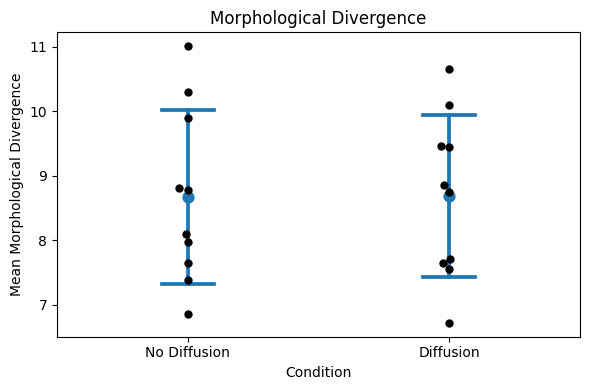

In [12]:
plt.figure(figsize=(6,4))

sns.pointplot(
    data=results,
    x="condition",
    y="morph_mean",
    errorbar="sd",
    capsize=.2,
    linestyle='none'
)

sns.swarmplot(
    data=results,
    x="condition",
    y="morph_mean",
    color="black",
    size=6
)
plt.title("Morphological Divergence")
plt.ylabel("Mean Morphological Divergence")
plt.xlabel("Condition")
plt.tight_layout()
plt.show()

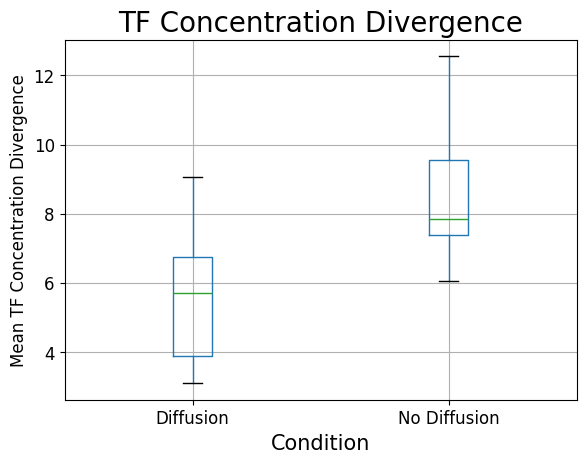

In [13]:
results.boxplot(
    column="tf_conc_mean",
    by="condition", fontsize=12

)

plt.title("TF Concentration Divergence", fontsize=20)
plt.suptitle("")
plt.ylabel("Mean TF Concentration Divergence", fontsize=12)
plt.xlabel("Condition", fontsize=15)
plt.show()

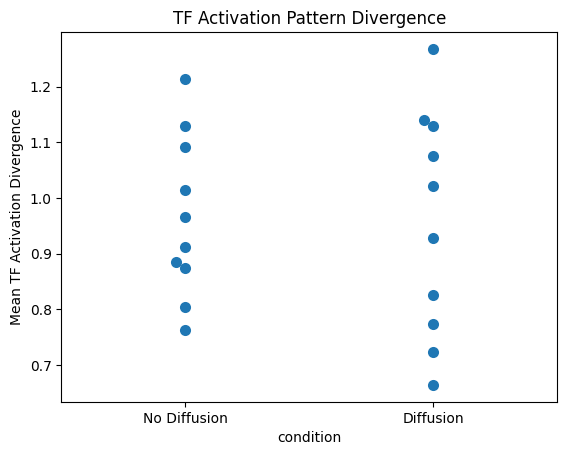

In [14]:
sns.swarmplot(
    data=results,
    x="condition",
    y="tf_act_mean",
    size=8
)

plt.title("TF Activation Pattern Divergence")
plt.ylabel("Mean TF Activation Divergence")
plt.show()

<Figure size 600x400 with 0 Axes>

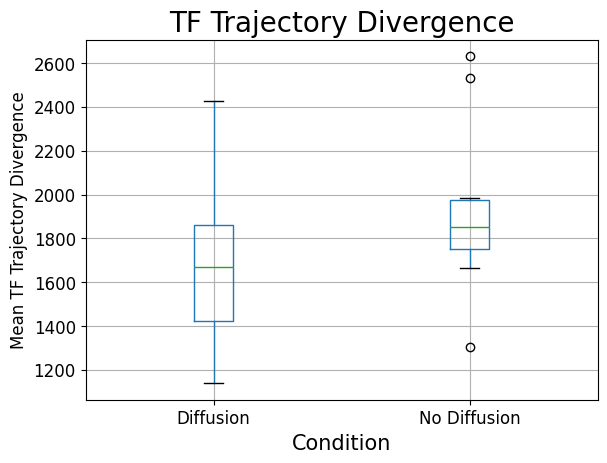

In [15]:
plt.figure(figsize=(6,4))

results.boxplot(
    column="tf_traj_mean",
    by="condition", fontsize=12
)

plt.title("TF Trajectory Divergence", fontsize=20)
plt.suptitle("")
plt.ylabel("Mean TF Trajectory Divergence", fontsize=12)
plt.xlabel("Condition", fontsize=15)
plt.show()

In [16]:
def cohens_d(x, y):
    x = np.array(x)
    y = np.array(y)
    nx = len(x)
    ny = len(y)
    
    pooled_sd = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) +
         (ny - 1) * np.var(y, ddof=1))
        / (nx + ny - 2)
    )

    return (np.mean(x) - np.mean(y)) / pooled_sd

In [17]:
def get_pair(file_name):
    file_name = str(file_name)

    # works for: parent_child_metrics_diff1 / parent_child_metrics_noDiff1
    match = re.search(r'(?:diff|noDiff)(\d+)', file_name)
    if match:
        return int(match.group(1))

    # works for: run_1_diff / run_1_noDiff
    match = re.search(r'run_(\d+)', file_name)
    if match:
        return int(match.group(1))

    raise ValueError(f"Could not extract pair from: {file_name}")

results["condition"] = results["file"].apply(
    lambda x: "No Diffusion" if "noDiff" in str(x) else "Diffusion"
)

results["pair"] = results["file"].apply(get_pair)

results[["file", "pair", "condition"]].sort_values(["pair", "condition"])

,file,pair,condition
3,parent_child_metrics_diff1,1,Diffusion
17,parent_child_metrics_noDiff1,1,No Diffusion
2,parent_child_metrics_diff2,2,Diffusion
19,parent_child_metrics_noDiff2,2,No Diffusion
1,parent_child_metrics_diff3,3,Diffusion
18,parent_child_metrics_noDiff3,3,No Diffusion
6,parent_child_metrics_diff4,4,Diffusion
16,parent_child_metrics_noDiff4,4,No Diffusion
5,parent_child_metrics_diff5,5,Diffusion
12,parent_child_metrics_noDiff5,5,No Diffusion


In [18]:
def paired_cohens_d(diff_values, nodiff_values):
    delta = diff_values - nodiff_values
    return delta.mean() / delta.std(ddof=1)

def paired_statistical_summary(results):
    metrics = [
        "morph_mean",
        "tf_conc_mean",
        "tf_act_mean",
        "tf_traj_mean"
    ]

    rows = []

    for metric in metrics:
        paired = results.pivot(index="pair", columns="condition", values=metric).dropna()

        diff_values = paired["Diffusion"]
        nodiff_values = paired["No Diffusion"]
        delta = diff_values - nodiff_values

        if len(delta) > 1:
            stat, p = wilcoxon(diff_values, nodiff_values)
            d = paired_cohens_d(diff_values, nodiff_values)
        else:
            p = None
            d = None

        rows.append({
            "metric": metric,
            "diff_mean": diff_values.mean(),
            "nodiff_mean": nodiff_values.mean(),
            "mean_pair_difference": delta.mean(),
            "p_value_paired": p,
            "paired_cohens_d": d
        })

    return pd.DataFrame(rows)

paired_stats = paired_statistical_summary(results)
paired_stats_rounded = paired_stats.copy()

numeric_cols = [
    "diff_mean",
    "nodiff_mean",
    "mean_pair_difference",
    "p_value_paired",
    "paired_cohens_d"
]

paired_stats_rounded[numeric_cols] = (
    paired_stats_rounded[numeric_cols].round(2)
)

paired_stats_rounded.reset_index(drop=True, inplace=True)

paired_stats_rounded

,metric,diff_mean,nodiff_mean,mean_pair_difference,p_value_paired,paired_cohens_d
0,morph_mean,8.69,8.67,0.01,0.85,0.01
1,tf_conc_mean,5.54,8.46,-2.92,0.01,-1.10
2,tf_act_mean,0.95,0.97,-0.01,0.92,-0.06
3,tf_traj_mean,1661.74,1928.26,-266.52,0.13,-0.55


# GENERATION PLOTS

In [19]:
def get_pair(file_name):
    # Works for parent_child_metrics_diff1 / parent_child_metrics_noDiff1
    match = re.search(r'(?:diff|noDiff)(\d+)$', file_name)
    if match:
        return int(match.group(1))

    # Works for future names like parent_child_metrics_run_1_diff
    match = re.search(r'run_(\d+)', file_name)
    if match:
        return int(match.group(1))

    raise ValueError(f"Could not extract pair from {file_name}")

results["condition"] = results["file"].apply(
    lambda x: "No Diffusion" if "noDiff" in x else "Diffusion"
)

results["pair"] = results["file"].apply(get_pair)

results[["file", "pair", "condition"]].sort_values(["pair", "condition"])

,file,pair,condition
3,parent_child_metrics_diff1,1,Diffusion
17,parent_child_metrics_noDiff1,1,No Diffusion
2,parent_child_metrics_diff2,2,Diffusion
19,parent_child_metrics_noDiff2,2,No Diffusion
1,parent_child_metrics_diff3,3,Diffusion
18,parent_child_metrics_noDiff3,3,No Diffusion
6,parent_child_metrics_diff4,4,Diffusion
16,parent_child_metrics_noDiff4,4,No Diffusion
5,parent_child_metrics_diff5,5,Diffusion
12,parent_child_metrics_noDiff5,5,No Diffusion


In [20]:
generation_results["condition"] = generation_results["file"].apply(
    lambda x: "No Diffusion" if "noDiff" in x else "Diffusion")

In [21]:
generation_results["pair"] = (
    generation_results["file"]
    .str.extract(r"(\d+)")
    .astype(int)
)

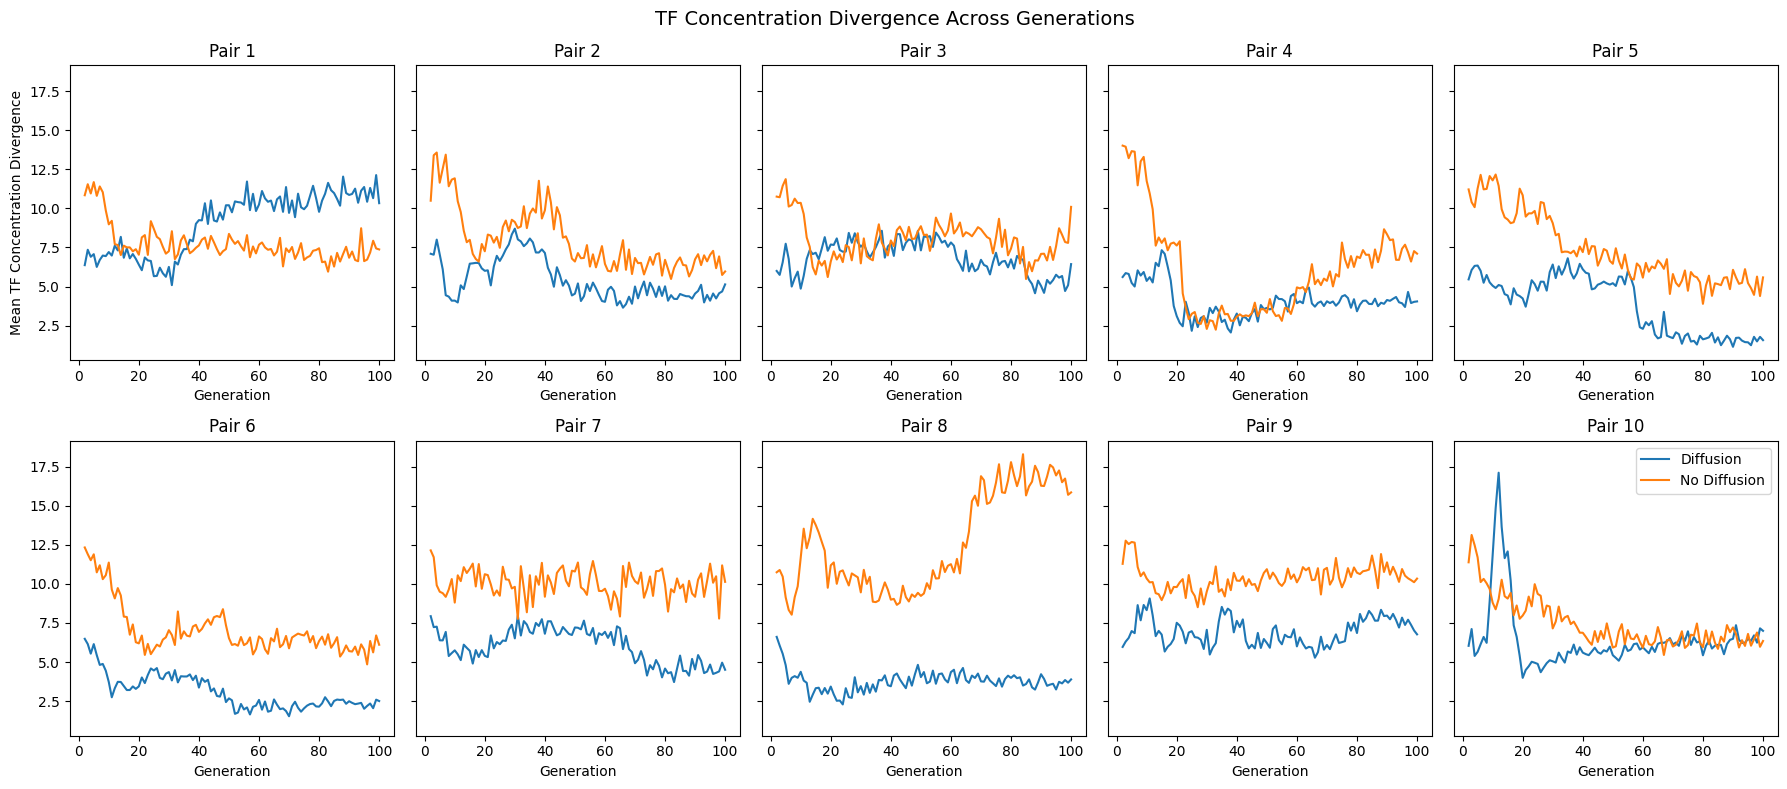

In [22]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 8),
    sharey=True
)

axes = axes.flatten()

for ax, pair in zip(axes, sorted(generation_results["pair"].unique())):

    pair_data = generation_results[
        generation_results["pair"] == pair
    ]

    for condition in ["Diffusion", "No Diffusion"]:

        subset = pair_data[
            pair_data["condition"] == condition
        ]

        ax.plot(
            subset["generation"],
            subset["tf_conc_mean"],
            #marker="o",
            label=condition
        )

    ax.set_title(f"Pair {pair}")
    ax.set_xlabel("Generation")

axes[0].set_ylabel("Mean TF Concentration Divergence")
axes[-1].legend()

plt.suptitle(
    "TF Concentration Divergence Across Generations",
    fontsize=14
)

plt.tight_layout()
plt.show()

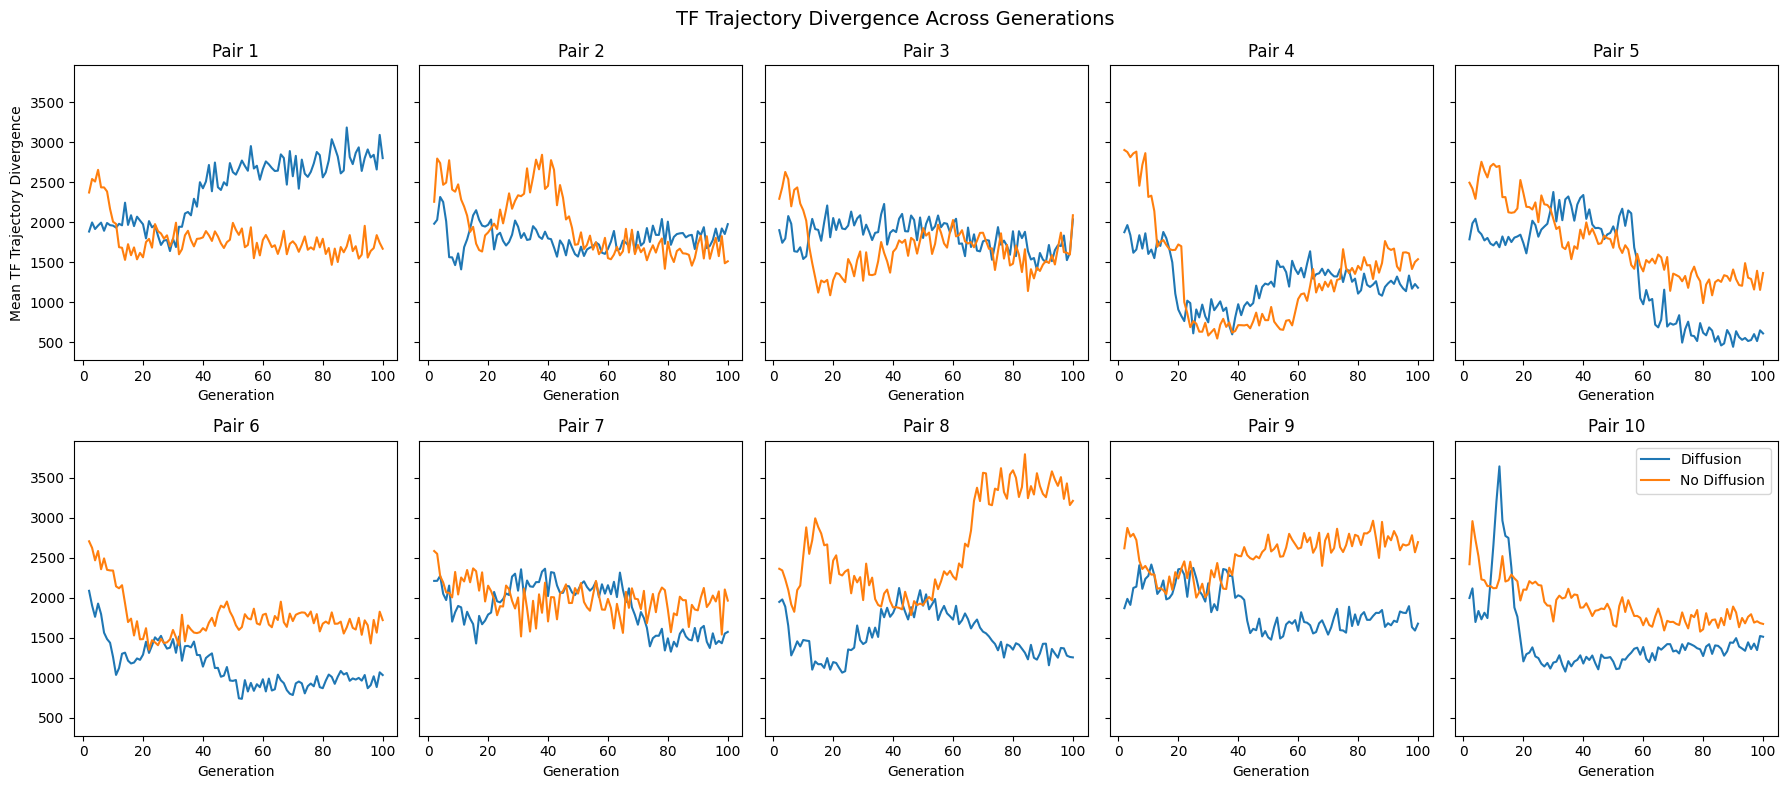

In [23]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 8),
    sharey=True
)

axes = axes.flatten()

for ax, pair in zip(axes, sorted(generation_results["pair"].unique())):

    pair_data = generation_results[
        generation_results["pair"] == pair
    ]

    for condition in ["Diffusion", "No Diffusion"]:

        subset = pair_data[
            pair_data["condition"] == condition
        ]

        ax.plot(
            subset["generation"],
            subset["tf_traj_mean"],
            #marker="o",
            label=condition
        )

    ax.set_title(f"Pair {pair}")
    ax.set_xlabel("Generation")

axes[0].set_ylabel("Mean TF Trajectory Divergence")
axes[-1].legend()

plt.suptitle(
    "TF Trajectory Divergence Across Generations",
    fontsize=14
)

plt.tight_layout()
plt.show()

# FITNESS PLOTS (HOPEFULLY)

In [24]:
base_path = Path("../tmp_out/evobots/evobots")

for folder in sorted(base_path.glob("run_run_*")):
    print("\nFOLDER:", folder)
    for item in folder.iterdir():
        print("  ", item.name, "DIR" if item.is_dir() else "FILE")

In [25]:
base_path = Path("../evogym-GRN/tmp_out/evobots/evobots")

def get_pair(name):
    return int(re.search(r"run_(\d+)", name).group(1))

def get_condition(name):
    return "No Diffusion" if "noDiff" in name else "Diffusion"

runs = [
    "run_1_diff",
    "run_1_noDiff",
    "run_2_diff",
    "run_2_noDiff",
    "run_3_diff",
    "run_3_noDiff",
    "run_4_diff",
    "run_4_noDiff",
    "run_5_diff",
    "run_5_noDiff",
    "run_6_diff",
    "run_6_noDiff",
    "run_7_diff",
    "run_7_noDiff",
    "run_8_diff",
    "run_8_noDiff",
    "run_9_diff",
    "run_9_noDiff",
    "run_10_diff",
    "run_10_noDiff",
]

fitness_dfs = []

for run_name in runs:
    folder_path = base_path / f"run_{run_name}" 
    print("Folder:", folder_path)

    candidates = [
        p for p in folder_path.iterdir()
        if p.is_file()
        and not p.name.endswith(".csv")
        and not p.name.startswith(".")
    ]

    print("DB candidates:", candidates)

    db_path = candidates[0]

    conn = sqlite3.connect(str(db_path))

    survivors = pd.read_sql_query(
        """
        SELECT generation, fitness
        FROM generation_survivors
        """,
        conn
    )

    conn.close()

    fitness_curve = (
        survivors
        .groupby("generation")["fitness"]
        .max()
        .reset_index()
    )

    fitness_curve["file"] = run_name
    fitness_curve["condition"] = get_condition(run_name)
    fitness_curve["pair"] = get_pair(run_name)

    fitness_dfs.append(fitness_curve)

fitness_data = pd.concat(fitness_dfs, ignore_index=True)

final_fitness = (
    fitness_data[fitness_data["generation"] == fitness_data["generation"].max()]
    .sort_values(["pair", "condition"])
)

final_fitness

Folder: ../evogym-GRN/tmp_out/evobots/evobots/run_run_1_diff
DB candidates: [PosixPath('../evogym-GRN/tmp_out/evobots/evobots/run_run_1_diff/run_run_1_diff')]
Folder: ../evogym-GRN/tmp_out/evobots/evobots/run_run_1_noDiff
DB candidates: [PosixPath('../evogym-GRN/tmp_out/evobots/evobots/run_run_1_noDiff/run_run_1_noDiff')]
Folder: ../evogym-GRN/tmp_out/evobots/evobots/run_run_2_diff
DB candidates: [PosixPath('../evogym-GRN/tmp_out/evobots/evobots/run_run_2_diff/run_run_2_diff')]
Folder: ../evogym-GRN/tmp_out/evobots/evobots/run_run_2_noDiff
DB candidates: [PosixPath('../evogym-GRN/tmp_out/evobots/evobots/run_run_2_noDiff/run_run_2_noDiff')]
Folder: ../evogym-GRN/tmp_out/evobots/evobots/run_run_3_diff
DB candidates: [PosixPath('../evogym-GRN/tmp_out/evobots/evobots/run_run_3_diff/run_run_3_diff')]
Folder: ../evogym-GRN/tmp_out/evobots/evobots/run_run_3_noDiff
DB candidates: [PosixPath('../evogym-GRN/tmp_out/evobots/evobots/run_run_3_noDiff/run_run_3_noDiff')]
Folder: ../evogym-GRN/tmp_ou

,generation,fitness,file,condition,pair
99,100,54.708384,run_1_diff,Diffusion,1
199,100,51.268617,run_1_noDiff,No Diffusion,1
299,100,64.199804,run_2_diff,Diffusion,2
399,100,56.381404,run_2_noDiff,No Diffusion,2
499,100,68.791561,run_3_diff,Diffusion,3
599,100,52.831754,run_3_noDiff,No Diffusion,3
699,100,76.329286,run_4_diff,Diffusion,4
799,100,36.941535,run_4_noDiff,No Diffusion,4
899,100,37.115839,run_5_diff,Diffusion,5
999,100,41.749729,run_5_noDiff,No Diffusion,5


Folder: ../evogym-GRN/tmp_out/evobots/evobots/run_run_9_noDiff
DB candidates: [PosixPath('../evogym-GRN/tmp_out/evobots/evobots/run_run_9_noDiff/run_run_9_noDiff')]
Folder: ../evogym-GRN/tmp_out/evobots/evobots/run_run_10_diff
DB candidates: [PosixPath('../evogym-GRN/tmp_out/evobots/evobots/run_run_10_diff/run_run_10_diff')]
Folder: ../evogym-GRN/tmp_out/evobots/evobots/run_run_10_noDiff
DB candidates: [PosixPath('../evogym-GRN/tmp_out/evobots/evobots/run_run_10_noDiff/run_run_10_noDiff')]


,generation,fitness,file,condition,pair
99,100,54.708384,run_1_diff,Diffusion,1
199,100,51.268617,run_1_noDiff,No Diffusion,1
299,100,64.199804,run_2_diff,Diffusion,2
399,100,56.381404,run_2_noDiff,No Diffusion,2
499,100,68.791561,run_3_diff,Diffusion,3
599,100,52.831754,run_3_noDiff,No Diffusion,3
699,100,76.329286,run_4_diff,Diffusion,4
799,100,36.941535,run_4_noDiff,No Diffusion,4
899,100,37.115839,run_5_diff,Diffusion,5
999,100,41.749729,run_5_noDiff,No Diffusion,5


In [26]:
final_fitness = (
    fitness_data[fitness_data["generation"] == 100]
    .sort_values(["pair", "condition"])
)

final_fitness

,generation,fitness,file,condition,pair
99,100,54.708384,run_1_diff,Diffusion,1
199,100,51.268617,run_1_noDiff,No Diffusion,1
299,100,64.199804,run_2_diff,Diffusion,2
399,100,56.381404,run_2_noDiff,No Diffusion,2
499,100,68.791561,run_3_diff,Diffusion,3
599,100,52.831754,run_3_noDiff,No Diffusion,3
699,100,76.329286,run_4_diff,Diffusion,4
799,100,36.941535,run_4_noDiff,No Diffusion,4
899,100,37.115839,run_5_diff,Diffusion,5
999,100,41.749729,run_5_noDiff,No Diffusion,5


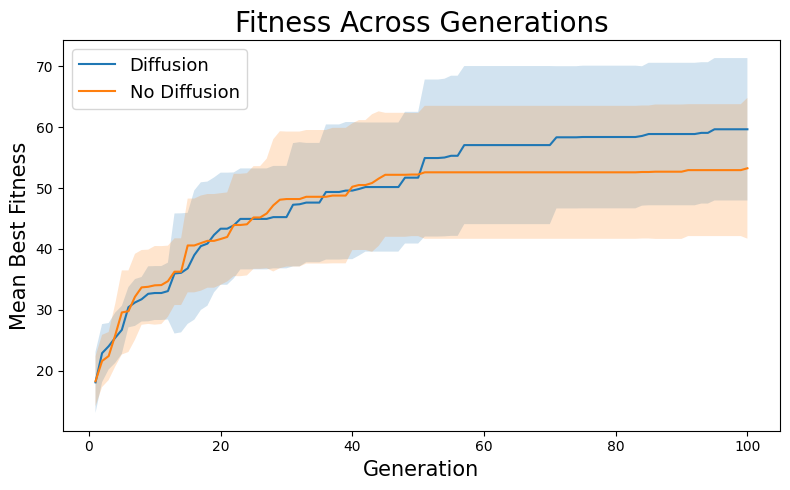

In [27]:
fitness_summary = (
    fitness_data
    .groupby(["condition", "generation"])["fitness"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(8,5))

for condition in ["Diffusion", "No Diffusion"]:
    subset = fitness_summary[fitness_summary["condition"] == condition]

    plt.plot(
        subset["generation"],
        subset["mean"],
        label=condition
    )

    plt.fill_between(
        subset["generation"],
        subset["mean"] - subset["std"],
        subset["mean"] + subset["std"],
        alpha=0.2
    )

plt.title("Fitness Across Generations", fontsize=20)
plt.xlabel("Generation", fontsize=15)
plt.ylabel("Mean Best Fitness", fontsize=15)
plt.legend(
    fontsize=13,
    handlelength=2,
)
plt.tight_layout()
plt.show()

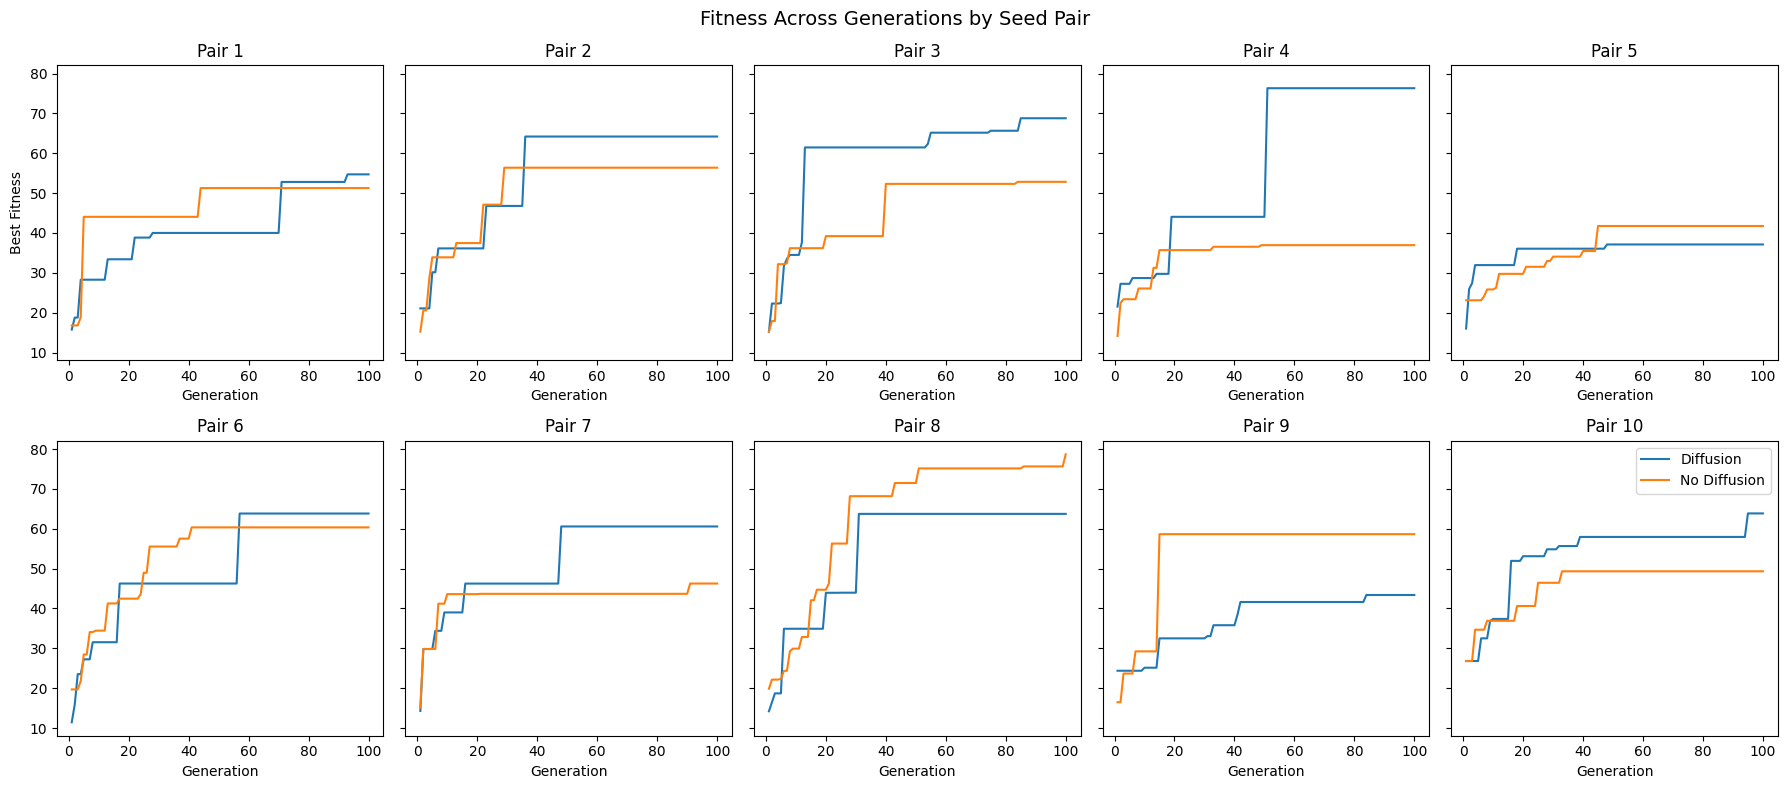

In [28]:
pairs = sorted(fitness_data["pair"].unique())

fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 8),
    sharey=True
)

axes = axes.flatten()

if len(pairs) == 1:
    axes = [axes]

for ax, pair in zip(axes, pairs):
    pair_data = fitness_data[fitness_data["pair"] == pair]

    for condition in ["Diffusion", "No Diffusion"]:
        subset = pair_data[pair_data["condition"] == condition]

        ax.plot(
            subset["generation"],
            subset["fitness"],
            label=condition
        )

    ax.set_title(f"Pair {pair}")
    ax.set_xlabel("Generation")

axes[0].set_ylabel("Best Fitness")
axes[-1].legend()

plt.suptitle("Fitness Across Generations by Seed Pair", fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
diff = final_fitness[
    final_fitness["condition"] == "Diffusion"
]["fitness"].values

nodiff = final_fitness[
    final_fitness["condition"] == "No Diffusion"
]["fitness"].values

stat, p = wilcoxon(diff, nodiff)

fitness_stats = pd.DataFrame({
    "diff_mean": [diff.mean()],
    "nodiff_mean": [nodiff.mean()],
    "mean_difference": [(diff - nodiff).mean()],
    "wilcoxon_stat": [stat],
    "p_value": [p]
})

fitness_stats.style.format("{:.2f}").hide(axis="index")

diff_mean,nodiff_mean,mean_difference,wilcoxon_stat,p_value
59.65,53.25,6.41,18.00,0.38


# MORE METRICS

In [30]:
robot_dfs = []

for run_name in runs:

    folder_path = base_path / f"run_{run_name}"

    candidates = [
        p for p in folder_path.iterdir()
        if p.is_file()
        and not p.name.endswith(".csv")
        and not p.name.startswith(".")
    ]

    db_path = candidates[0]

    conn = sqlite3.connect(str(db_path))

    robots = pd.read_sql_query(
        """
        SELECT
            born_generation,
            num_voxels,
            genome_size,
            bone_prop,
            fat_prop,
            phase_muscle_prop,
            offphase_muscle_prop
        FROM all_robots
        """,
        conn
    )

    conn.close()

    robots["condition"] = get_condition(run_name)
    robots["pair"] = get_pair(run_name)

    robot_dfs.append(robots)

robot_data = pd.concat(robot_dfs, ignore_index=True)

In [31]:
voxels_summary = (
    robot_data
    .groupby(["condition", "born_generation"])["num_voxels"]
    .mean()
    .reset_index()
)

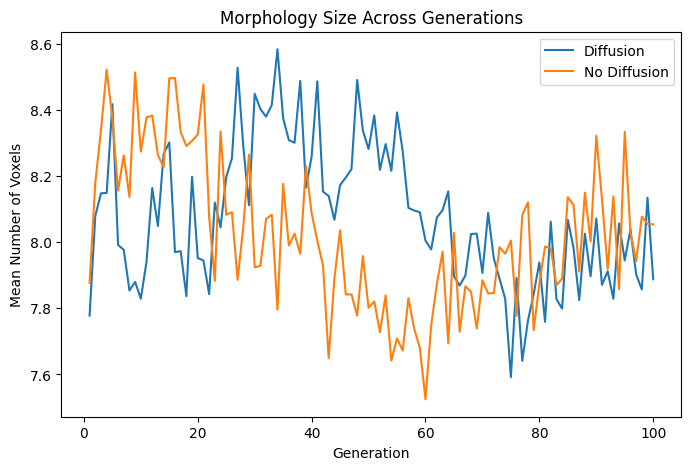

In [32]:
plt.figure(figsize=(8,5))

for condition in ["Diffusion", "No Diffusion"]:
    subset = voxels_summary[
        voxels_summary["condition"] == condition
    ]

    plt.plot(
        subset["born_generation"],
        subset["num_voxels"],
        label=condition
    )

plt.xlabel("Generation")
plt.ylabel("Mean Number of Voxels")
plt.title("Morphology Size Across Generations")
plt.legend()
plt.show()

In [33]:
genome_summary = (
    robot_data
    .groupby(["condition", "born_generation"])["genome_size"]
    .mean()
    .reset_index()
)

genome_summary.head()

,condition,born_generation,genome_size
0,Diffusion,1,301.000
1,Diffusion,2,301.216
2,Diffusion,3,301.471
3,Diffusion,4,301.455
4,Diffusion,5,301.810


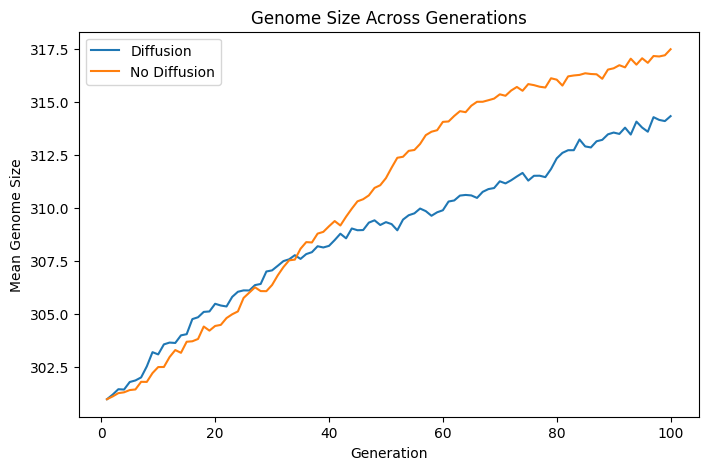

In [34]:
plt.figure(figsize=(8,5))

for condition in ["Diffusion", "No Diffusion"]:
    subset = genome_summary[
        genome_summary["condition"] == condition
    ]

    plt.plot(
        subset["born_generation"],
        subset["genome_size"],
        label=condition
    )

plt.xlabel("Generation")
plt.ylabel("Mean Genome Size")
plt.title("Genome Size Across Generations")
plt.legend()
plt.show()

In [35]:
bone_summary = (
    robot_data
    .groupby(["condition","born_generation"])["bone_prop"]
    .mean()
    .reset_index()
)

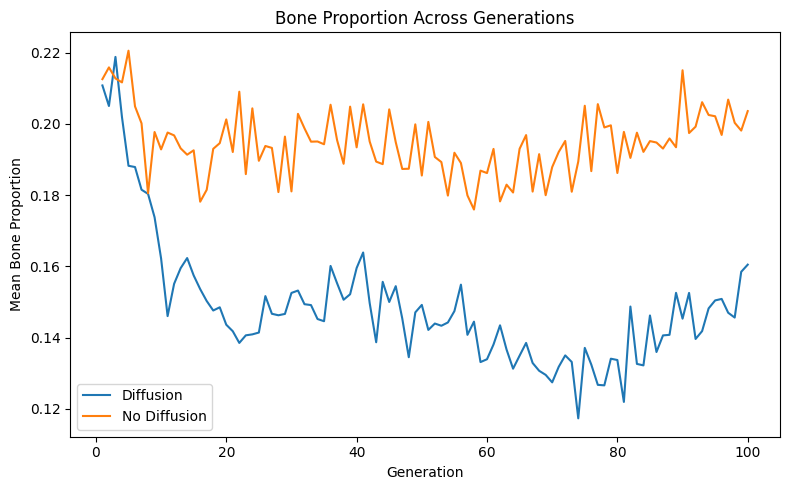

In [36]:
plt.figure(figsize=(8,5))

for condition in ["Diffusion", "No Diffusion"]:
    subset = bone_summary[bone_summary["condition"] == condition]

    plt.plot(
        subset["born_generation"],
        subset["bone_prop"],
        label=condition
    )

plt.xlabel("Generation")
plt.ylabel("Mean Bone Proportion")
plt.title("Bone Proportion Across Generations")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
phase_summary = (
    robot_data
    .groupby(["condition","born_generation"])["phase_muscle_prop"]
    .mean()
    .reset_index()
)

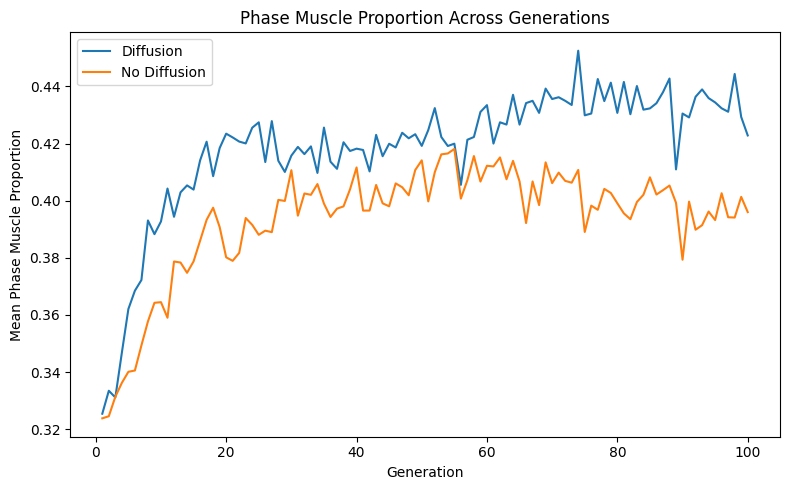

In [38]:
plt.figure(figsize=(8,5))

for condition in ["Diffusion", "No Diffusion"]:
    subset = phase_summary[phase_summary["condition"] == condition]

    plt.plot(
        subset["born_generation"],
        subset["phase_muscle_prop"],
        label=condition
    )

plt.xlabel("Generation")
plt.ylabel("Mean Phase Muscle Proportion")
plt.title("Phase Muscle Proportion Across Generations")
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
final_genome = (
    robot_data[robot_data["born_generation"] == 100]
    .groupby(["condition","pair"])["genome_size"]
    .mean()
    .reset_index()
)

In [40]:
diff_genome = final_genome[
    final_genome["condition"] == "Diffusion"
].sort_values("pair")["genome_size"].values

nodiff_genome = final_genome[
    final_genome["condition"] == "No Diffusion"
].sort_values("pair")["genome_size"].values

stat, p = wilcoxon(diff_genome, nodiff_genome)

print("Diffusion final genome mean:", diff_genome.mean())
print("No Diffusion final genome mean:", nodiff_genome.mean())
print("Mean pair difference:", (diff_genome - nodiff_genome).mean())
print("Wilcoxon statistic:", stat)
print("p-value:", p)

Diffusion final genome mean: 314.323
No Diffusion final genome mean: 317.47200000000004
Mean pair difference: -3.149000000000001
Wilcoxon statistic: 15.0
p-value: 0.232421875


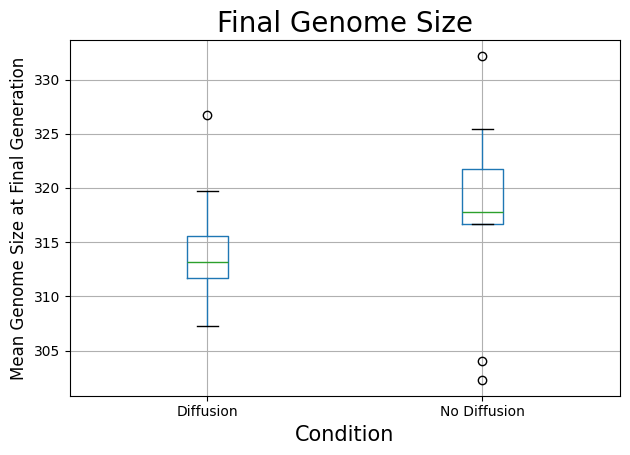

In [41]:
final_genome.boxplot(
    column="genome_size",
    by="condition"
)

plt.title("Final Genome Size", fontsize=20)
plt.suptitle("")
plt.ylabel("Mean Genome Size at Final Generation", fontsize=12)
plt.xlabel("Condition", fontsize=15)
plt.tight_layout()
plt.show()

# AAAA

In [42]:
files = list(Path(".").glob("parent_child_metrics_*.csv"))

dfs = []

for f in files:

    df = pd.read_csv(f)

    if "noDiff" in f.name:
        df["condition"] = "No Diffusion"
    else:
        df["condition"] = "Diffusion"

    dfs.append(df)

metrics = pd.concat(dfs, ignore_index=True)

metrics.head()

,seed,generation,child_id,parent1_id,parent2_id,morph_diff_p1,morph_diff_p2,tf_diff_p1,tf_diff_p2,activation_diff_p1,activation_diff_p2,trajectory_diff_p1,trajectory_diff_p2,condition
0,1675610640,2,101,19,80,12,8,9.6922,7.0050,2,3,2273.0531,1011.4455,No Diffusion
1,1675610640,2,102,87,4,11,9,10.5366,9.8563,0,1,1248.0188,2247.3008,No Diffusion
2,1675610640,2,103,22,37,10,7,19.5953,10.1380,0,2,3223.8169,2634.8280,No Diffusion
3,1675610640,2,104,87,49,9,10,9.3969,26.7479,0,0,2442.9604,4716.9151,No Diffusion
4,1675610640,2,105,89,18,12,7,13.7958,8.5429,1,2,2920.8855,1961.7362,No Diffusion


In [43]:
generation_metrics = (
    metrics
    .groupby(
        ["condition", "generation"]
    )
    .agg({
        "morph_diff_p1": "mean",
        "tf_diff_p1": "mean",
        "activation_diff_p1": "mean",
        "trajectory_diff_p1": "mean"
    })
    .reset_index()
)

In [44]:
summary = (
    generation_metrics
    .groupby(
        ["condition", "generation"]
    )
    .agg({
        "morph_diff_p1": ["mean", "std"],
        "tf_diff_p1": ["mean", "std"],
        "activation_diff_p1": ["mean", "std"],
        "trajectory_diff_p1": ["mean", "std"]
    })
)

In [45]:
summary.columns = [
    "_".join(col).strip("_")
    for col in summary.columns
]

summary = summary.reset_index()

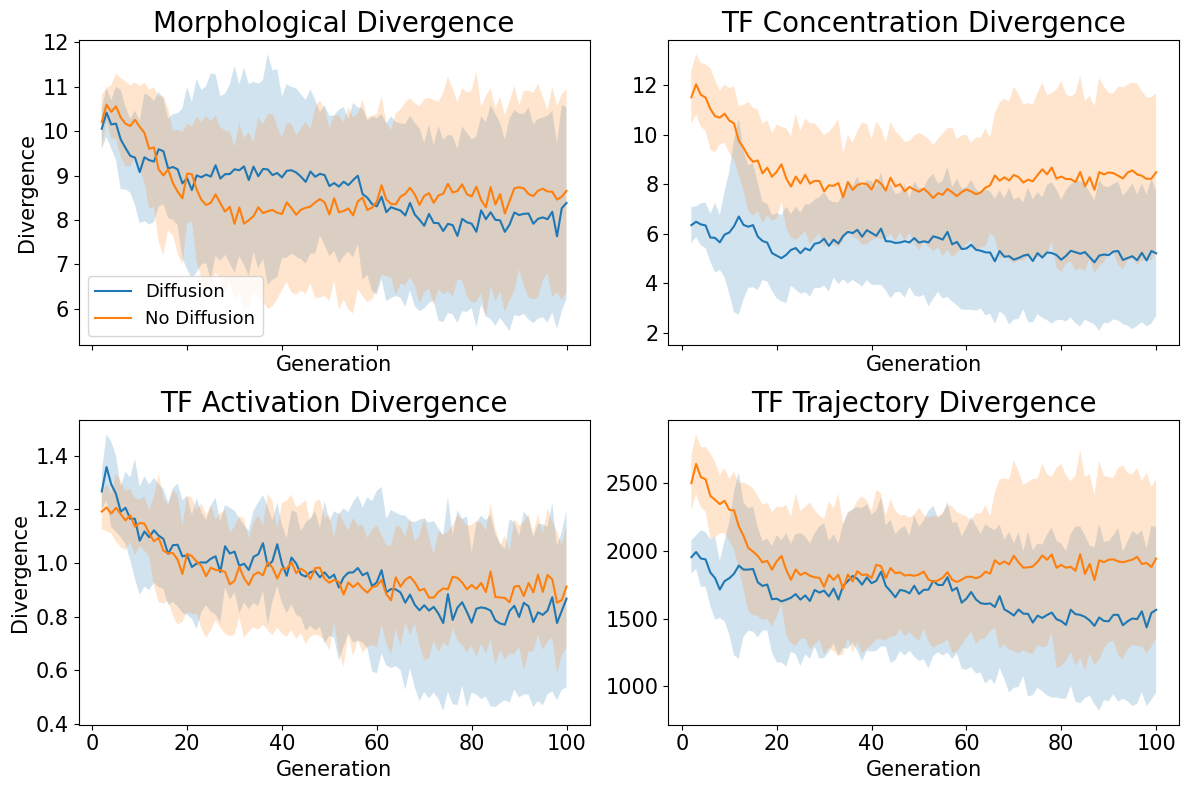

In [46]:
metrics_to_plot = [
    ("morph_mean", "Morphological Divergence"),
    ("tf_conc_mean", "TF Concentration Divergence"),
    ("tf_act_mean", "TF Activation Divergence"),
    ("tf_traj_mean", "TF Trajectory Divergence"),
]

div_summary = (
    generation_results
    .groupby(["condition", "generation"])
    .agg({metric: ["mean", "std"] for metric, _ in metrics_to_plot})
)

div_summary.columns = ["_".join(col) for col in div_summary.columns]
div_summary = div_summary.reset_index()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics_to_plot):
    for condition in ["Diffusion", "No Diffusion"]:
        subset = div_summary[div_summary["condition"] == condition]

        mean = subset[f"{metric}_mean"]
        std = subset[f"{metric}_std"]

        ax.plot(subset["generation"], mean, label=condition)
        ax.fill_between(
            subset["generation"],
            mean - std,
            mean + std,
            alpha=0.2
        )

    ax.set_title(title, fontsize=20)
    ax.set_xlabel("Generation", fontsize=15)
    ax.tick_params(axis='both', labelsize=15)

axes[0].set_ylabel("Divergence", fontsize=15)
axes[2].set_ylabel("Divergence", fontsize=15)
axes[0].legend(
    fontsize=13,
    handlelength=2,
)
plt.tight_layout()
plt.show()

In [47]:
# how the metrics correlate intuitively with the body metrics, look at the videos, not claims unless can clearly prove -> discussion
# videos -> most representative examples of each set up, doesnt have to be the best, but the one that most illustrates the findings 
# add yt link to the data and the code 

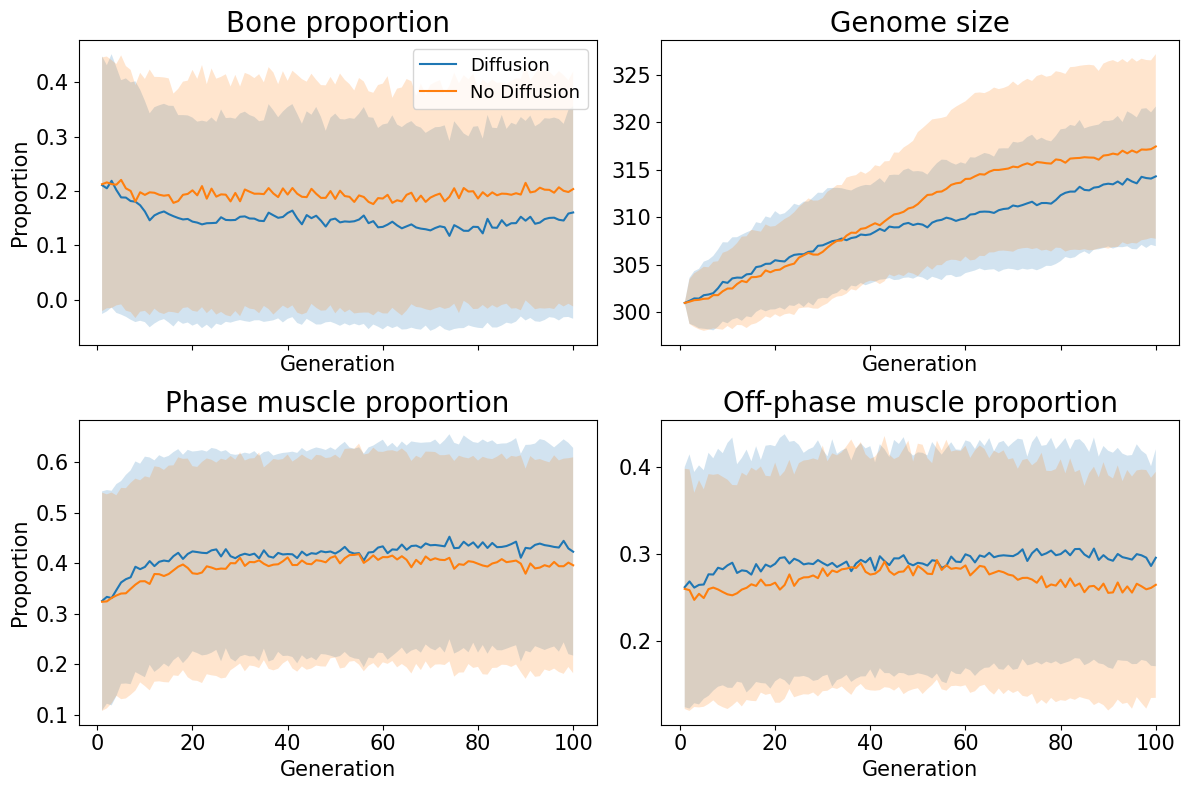

In [48]:
metrics_to_plot = [
    ("bone_prop", "Bone proportion"),
    ("genome_size", "Genome size"),
    ("phase_muscle_prop", "Phase muscle proportion"),
    ("offphase_muscle_prop", "Off-phase muscle proportion"),
]

summary = (
    robot_data
    .groupby(["condition", "born_generation"])
    .agg({m: ["mean", "std"] for m, _ in metrics_to_plot})
)

summary.columns = ["_".join(col) for col in summary.columns]
summary = summary.reset_index()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics_to_plot):
    for condition in ["Diffusion", "No Diffusion"]:
        subset = summary[summary["condition"] == condition]

        x = subset["born_generation"]
        mean = subset[f"{metric}_mean"]
        std = subset[f"{metric}_std"]

        ax.plot(x, mean, label=condition)
        ax.fill_between(x, mean - std, mean + std, alpha=0.2)

    ax.set_title(title, fontsize=20)
    ax.set_xlabel("Generation", fontsize=15)
    ax.tick_params(axis='both', labelsize=15)

axes[0].set_ylabel("Proportion", fontsize=15)
axes[2].set_ylabel("Proportion", fontsize=15)
axes[0].legend(
    fontsize=13,
    handlelength=2,
)
plt.tight_layout()
plt.show()

In [49]:
# also do for fitness
# how is it diff why is it relevant 
# cite how development has not been studied as much, motivate study of development 

# AAAAAAAAA

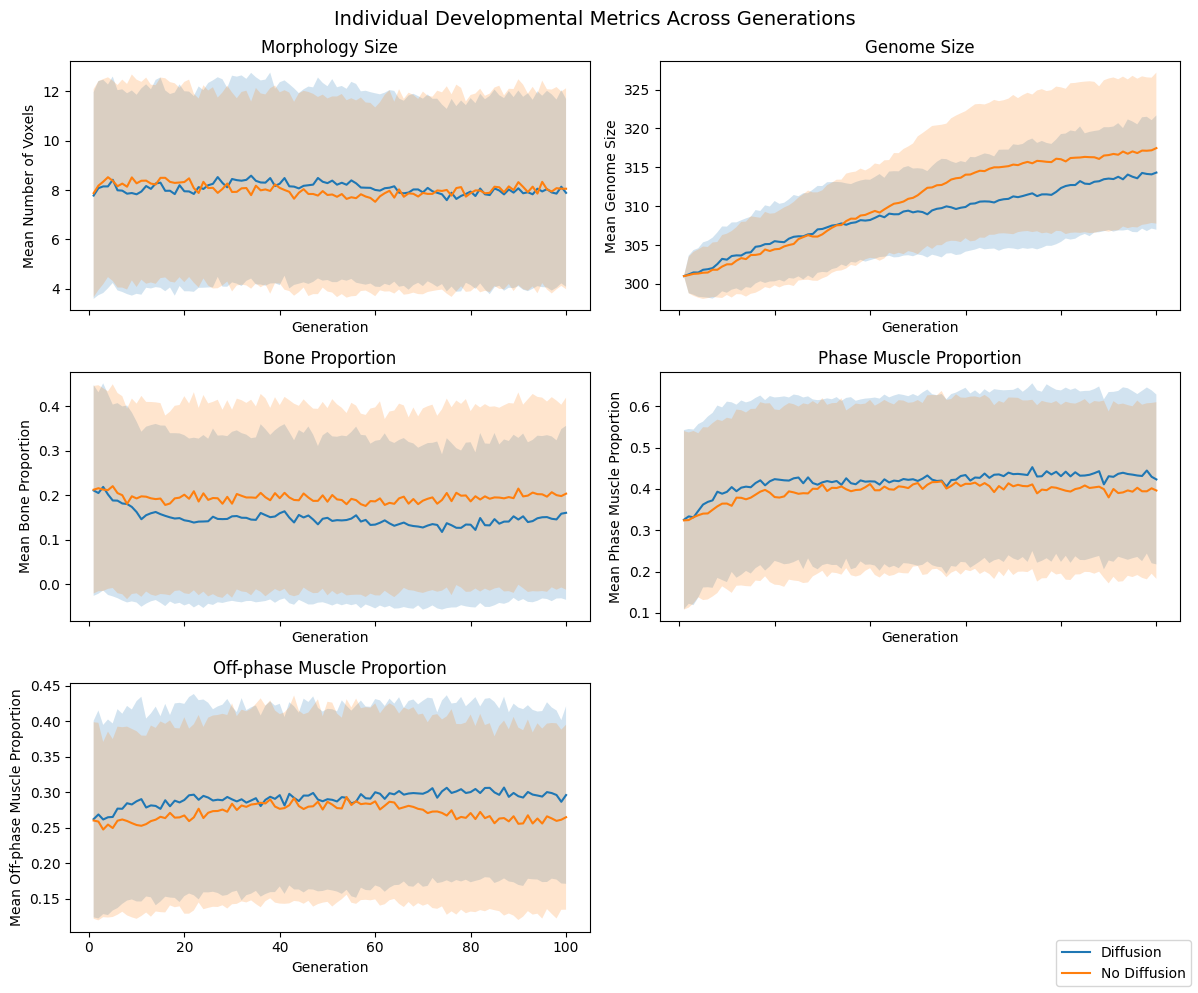

In [50]:
import matplotlib.pyplot as plt

pure_metrics = [
    ("num_voxels", "Morphology Size", "Mean Number of Voxels"),
    ("genome_size", "Genome Size", "Mean Genome Size"),
    ("bone_prop", "Bone Proportion", "Mean Bone Proportion"),
    ("phase_muscle_prop", "Phase Muscle Proportion", "Mean Phase Muscle Proportion"),
    ("offphase_muscle_prop", "Off-phase Muscle Proportion", "Mean Off-phase Muscle Proportion"),
]

summary = (
    robot_data
    .groupby(["condition", "born_generation"])
    .agg({metric: ["mean", "std"] for metric, _, _ in pure_metrics})
    .reset_index()
)

summary.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in summary.columns
]

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
axes = axes.flatten()

for ax, (metric, title, ylabel) in zip(axes, pure_metrics):
    for condition in ["Diffusion", "No Diffusion"]:
        subset = summary[summary["condition"] == condition]

        x = subset["born_generation"]
        y = subset[f"{metric}_mean"]
        yerr = subset[f"{metric}_std"]

        ax.plot(x, y, label=condition)
        ax.fill_between(x, y - yerr, y + yerr, alpha=0.2)

    ax.set_title(title)
    ax.set_xlabel("Generation")
    ax.set_ylabel(ylabel)

axes[-1].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right")

plt.suptitle("Individual Developmental Metrics Across Generations", fontsize=14)
plt.tight_layout()

plt.show()

# INDIVIDUAL-LEVEL DEVELOPMENTAL METRICS (not parent-child)

These metrics describe each individual's own TF concentration, TF activation, and TF trajectory at the end of development, instead of comparing them to a parent. They were recomputed by replaying GRN development directly from the genomes stored in the run databases (development is deterministic given the genome, so no re-evolution was needed).

In [51]:
individual_dfs = []

def get_individual_pair(filename):
    match = re.search(r"(?:diff|noDiff)(\d+)$", filename)
    if match:
        return int(match.group(1))
    raise ValueError(f"Could not extract pair from {filename}")

for file in Path(".").glob("individual_developmental_metrics_*.csv"):

    df = pd.read_csv(file)

    filename = file.stem

    df["condition"] = "No Diffusion" if "noDiff" in filename else "Diffusion"
    df["pair"] = get_individual_pair(filename)

    individual_dfs.append(df)

individual_data = pd.concat(individual_dfs, ignore_index=True)

print("Rows:", len(individual_data))
print("Files:", len(individual_dfs))

individual_data.head()


Rows: 200000
Files: 20


,seed,generation,individual_id,parent1_id,parent2_id,tf_concentration,num_active_tfs,trajectory_variability,condition,pair
0,2000041698,1,1,NaN,NaN,16.2387,2,31.9750,Diffusion,8
1,2000041698,1,2,NaN,NaN,1.6060,1,7.0234,Diffusion,8
2,2000041698,1,3,NaN,NaN,0.0063,0,27.6914,Diffusion,8
3,2000041698,1,4,NaN,NaN,7.6202,3,27.4700,Diffusion,8
4,2000041698,1,5,NaN,NaN,0.5184,0,11.2512,Diffusion,8


In [52]:
ind_metrics_to_plot = [
    ("tf_concentration", "TF Concentration", "Mean TF Concentration"),
    ("num_active_tfs", "TF Activation", "Mean Number of Active TFs"),
    ("trajectory_variability", "TF Trajectory Variability", "Mean Trajectory Variability"),
]

ind_summary = (
    individual_data
    .groupby(["condition", "generation"])
    .agg({metric: ["mean", "std"] for metric, _, _ in ind_metrics_to_plot})
    .reset_index()
)

ind_summary.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in ind_summary.columns
]

ind_summary.head()


,condition,generation,tf_concentration_mean,tf_concentration_std,num_active_tfs_mean,num_active_tfs_std,trajectory_variability_mean,trajectory_variability_std
0,Diffusion,1,4.904811,5.001096,1.293,1.013004,32.138072,24.536594
1,Diffusion,2,5.363597,5.491259,1.387,1.041305,34.380550,26.052379
2,Diffusion,3,5.261724,5.217687,1.401,0.995585,35.125697,26.109962
3,Diffusion,4,5.226792,5.161424,1.368,0.995775,34.312635,24.917123
4,Diffusion,5,5.531106,5.720733,1.421,1.010336,36.747718,26.086280


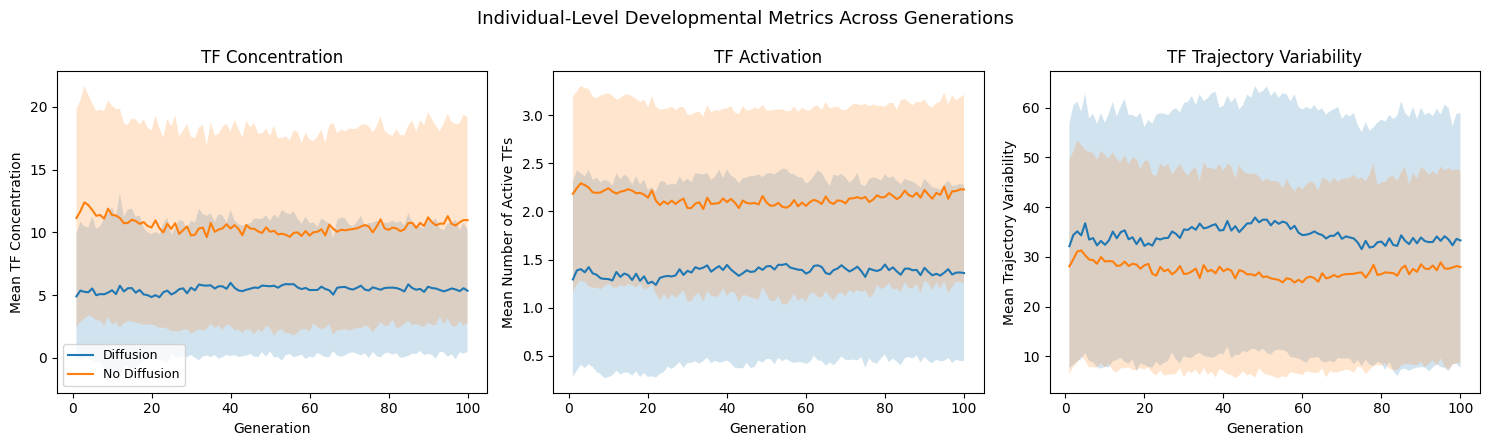

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)

for ax, (metric, title, ylabel) in zip(axes, ind_metrics_to_plot):
    for condition in ["Diffusion", "No Diffusion"]:
        subset = ind_summary[ind_summary["condition"] == condition]

        x = subset["generation"]
        y = subset[f"{metric}_mean"]
        yerr = subset[f"{metric}_std"]

        ax.plot(x, y, label=condition)
        ax.fill_between(x, y - yerr, y + yerr, alpha=0.2)

    ax.set_title(title)
    ax.set_xlabel("Generation")
    ax.set_ylabel(ylabel)

axes[0].legend(loc="lower left", fontsize=9)

plt.suptitle("Individual-Level Developmental Metrics Across Generations", fontsize=13)
plt.tight_layout()

plt.show()


## Distribution of individual-level metrics (Diffusion vs No Diffusion)

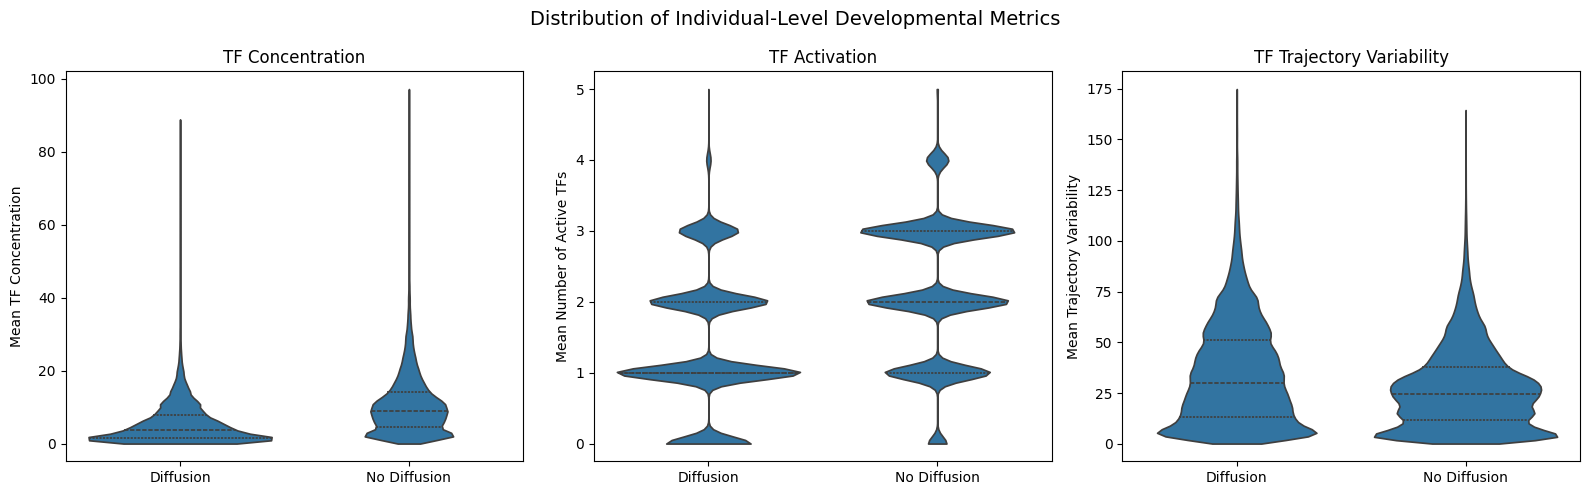

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric, title, ylabel) in zip(axes, ind_metrics_to_plot):
    sns.violinplot(
        data=individual_data,
        x="condition",
        y=metric,
        order=["Diffusion", "No Diffusion"],
        cut=0,
        inner="quartile",
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

plt.suptitle("Distribution of Individual-Level Developmental Metrics", fontsize=14)
plt.tight_layout()

plt.show()


## Statistical comparison (paired by seed, individual-level metrics)

In [55]:
pair_summary = (
    individual_data
    .groupby(["condition", "pair"])
    .agg({metric: "mean" for metric, _, _ in ind_metrics_to_plot})
    .reset_index()
)

rows = []

for metric, title, _ in ind_metrics_to_plot:
    paired = pair_summary.pivot(index="pair", columns="condition", values=metric).dropna()

    diff_values = paired["Diffusion"]
    nodiff_values = paired["No Diffusion"]
    delta = diff_values - nodiff_values

    if len(delta) > 1:
        stat, p = wilcoxon(diff_values, nodiff_values)
        d = paired_cohens_d(diff_values, nodiff_values)
    else:
        p = None
        d = None

    rows.append({
        "metric": title,
        "diff_mean": diff_values.mean(),
        "nodiff_mean": nodiff_values.mean(),
        "mean_pair_difference": delta.mean(),
        "p_value_paired": p,
        "paired_cohens_d": d
    })

individual_paired_stats = pd.DataFrame(rows)
individual_paired_stats_rounded = individual_paired_stats.copy()

numeric_cols = [
    "diff_mean",
    "nodiff_mean",
    "mean_pair_difference",
    "p_value_paired",
    "paired_cohens_d"
]
individual_paired_stats_rounded[numeric_cols] = individual_paired_stats_rounded[numeric_cols].round(4)

individual_paired_stats_rounded


,metric,diff_mean,nodiff_mean,mean_pair_difference,p_value_paired,paired_cohens_d
0,TF Concentration,5.4636,10.5014,-5.0378,0.0020,-2.6260
1,TF Activation,1.3736,2.1389,-0.7654,0.0020,-2.8193
2,TF Trajectory Variability,34.3899,27.2346,7.1553,0.0273,0.8536
